# Analiza datasetu do projektu - Fake News Detector — LIAR dataset

Cashowanie danych:

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

CACHE_DIR = '/content/drive/MyDrive/fakenews_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

DATA_DIR    = os.path.join(CACHE_DIR, 'data')
TOK_DIR     = os.path.join(CACHE_DIR, 'tokenized')
MODEL_DIR_2 = os.path.join(CACHE_DIR, 'model_roberta_2cl')
MODEL_DIR_6 = os.path.join(CACHE_DIR, 'model_roberta_6cl')
HF_CACHE    = os.path.join(CACHE_DIR, 'hf_cache')

for d in [DATA_DIR, TOK_DIR, MODEL_DIR_2, MODEL_DIR_6, HF_CACHE]:
    os.makedirs(d, exist_ok=True)

os.environ['HF_HOME'] = HF_CACHE
os.environ['TRANSFORMERS_CACHE'] = HF_CACHE

print('Cache dir:', CACHE_DIR)
print('Zawartosc:', os.listdir(CACHE_DIR))

Mounted at /content/drive
Cache dir: /content/drive/MyDrive/fakenews_cache
Zawartosc: ['data', 'tokenized', 'model_roberta_2cl', 'model_roberta_6cl', 'hf_cache']


In [3]:
import os, zipfile, urllib.request
import pandas as pd

URL = 'https://www.cs.ucsb.edu/~william/data/liar_dataset.zip'
ZIP_PATH = os.path.join(DATA_DIR, 'liar_dataset.zip')

os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(ZIP_PATH):
    print('Pobieram LIAR...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)
    print('Gotowe.')
else:
    print('Plik juz pobrany.')

print(os.listdir(DATA_DIR))

Plik juz pobrany.
['liar_dataset.zip', 'README', 'test.tsv', 'train.tsv', 'valid.tsv']


Wypisuję kolumny z readme:

In [4]:
COLUMNS = [
    'id', 'label', 'statement', 'subject', 'speaker', 'job_title',
    'state', 'party', 'barely_true_counts', 'false_counts',
    'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts',
    'context'
]

train = pd.read_csv(os.path.join(DATA_DIR, 'train.tsv'), sep='\t', header=None, names=COLUMNS)
valid = pd.read_csv(os.path.join(DATA_DIR, 'valid.tsv'), sep='\t', header=None, names=COLUMNS)
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.tsv'),  sep='\t', header=None, names=COLUMNS)

print(f'train: {train.shape}, valid: {valid.shape}, test: {test.shape}')
print('Kolumny:', list(train.columns))
train.head(5)

train: (10240, 14), valid: (1284, 14), test: (1267, 14)
Kolumny: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context']


,id,label,statement,subject,speaker,job_title,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


## Usuwam kolumny, które nie wnoszą sygnału do detekcji fake news

- id — identyfikator rekordu
- job_title, state — dane o mówcy (praca, stan)

In [5]:
cols_to_drop = ['id', 'job_title', 'state']

train = train.drop(columns=cols_to_drop)
valid = valid.drop(columns=cols_to_drop)
test  = test.drop(columns=cols_to_drop)

## Zmienna celu `y` = `label`

Kolumna `label` to nasza zmienna zależna (target). Sprawdzamy, jakie wartości może przyjmować.

In [6]:
labels_train = sorted(train['label'].unique())
print('Unikalne etykiety:', labels_train)

Unikalne etykiety: ['barely-true', 'false', 'half-true', 'mostly-true', 'pants-fire', 'true']


# Wersja z 6 etykietami dla wypowiedzi:

In [7]:
LABELS_6 = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
LABEL6_TO_INT = {l: i for i, l in enumerate(LABELS_6)}

train_6cl = train.copy()
valid_6cl = valid.copy()
test_6cl  = test.copy()

train_6cl['label'] = train_6cl['label'].map(LABEL6_TO_INT)
valid_6cl['label'] = valid_6cl['label'].map(LABEL6_TO_INT)
test_6cl['label']  = test_6cl['label'].map(LABEL6_TO_INT)

print('6kl train:', train_6cl['label'].value_counts().sort_index().to_dict())
print('6kl test :', test_6cl['label'].value_counts().sort_index().to_dict())

6kl train: {0: 839, 1: 1995, 2: 1654, 3: 2114, 4: 1962, 5: 1676}
6kl test : {0: 92, 1: 249, 2: 212, 3: 265, 4: 241, 5: 208}


#Procentowy rozklad klas - wersja datasetu z podzialem na 6 klas:

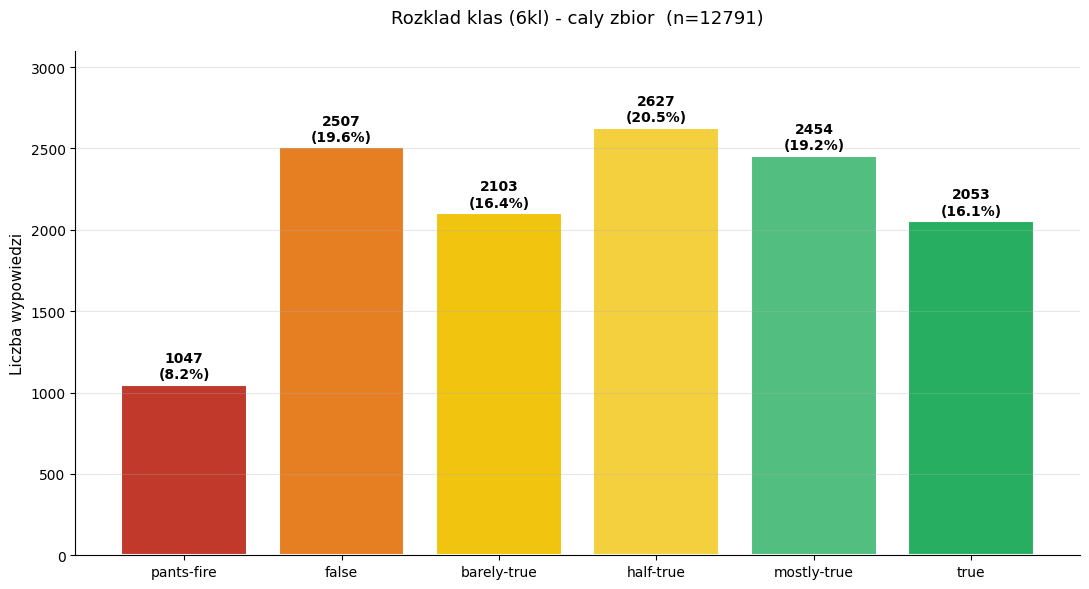

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

LABELS_6 = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
COLORS_6 = ['#c0392b', '#e67e22', '#f1c40f', '#f4d03f', '#52be80', '#27ae60']

all_df = pd.concat([train_6cl, valid_6cl, test_6cl], ignore_index=True)
counts = all_df['label'].value_counts().sort_index()
pcts = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(LABELS_6, counts.values, color=COLORS_6, edgecolor='white', linewidth=1.5)

for bar, c, p in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{c}\n({p:.1f}%)', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Liczba wypowiedzi', fontsize=11)
ax.set_title(f'Rozklad klas (6kl) - caly zbior  (n={len(all_df)})',
              fontsize=13, pad=20)
ax.set_ylim(0, counts.max() * 1.18)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## Zamiana etykiet tylko na true i false, sprawdzenie wielkości zbiorów

- **`false`** ← `pants-fire`, `false`, `barely-true`
- **`true`** ← `half-true`, `mostly-true`, `true`

In [9]:
LABEL_MAP = {
    'pants-fire':  'false',
    'false':       'false',
    'barely-true': 'false',
    'half-true':   'true',
    'mostly-true': 'true',
    'true':        'true',
}

train['label'] = train['label'].map(LABEL_MAP)
valid['label'] = valid['label'].map(LABEL_MAP)
test['label']  = test['label'].map(LABEL_MAP)

print('Rozklad etykiet po binaryzacji:')
print('train:', train['label'].value_counts().to_dict())
print('valid:', valid['label'].value_counts().to_dict())
print('test :', test['label'].value_counts().to_dict())

Rozklad etykiet po binaryzacji:
train: {'true': 5752, 'false': 4488}
valid: {'true': 668, 'false': 616}
test : {'true': 714, 'false': 553}


## Mapowanie etykiet `'true'`/`'false'` → `1`/`0`

In [10]:
LABEL_TO_INT = {'false': 0, 'true': 1}

train['label'] = train['label'].map(LABEL_TO_INT)
valid['label'] = valid['label'].map(LABEL_TO_INT)
test['label']  = test['label'].map(LABEL_TO_INT)

print(train['label'].value_counts().to_dict())

{1: 5752, 0: 4488}


## Preprocessing tekstu — wersja do porównania

Tworzę drugą wersję zbioru danych - z preprocessingiem (lowercase, usunięcie URL-i, interpunkcji, cyfr w słowach). Później chcę trenować RoBERTę na obu wersjach (surowej i przetworzonej) i porównać wyniki. ! Wazne ze interpunkcja wpływa na styl wypowiedzi, więc pytanie czy to nie obnizy jakosci wyniku ???

! todo: zobaczyc ilosc tokenow na wersji preprocessed, moze bedzie mozna wziac mniejsza ilosc niz 128

In [11]:
import re
import string

def preprocess(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_prep = train.copy()
valid_prep = valid.copy()
test_prep  = test.copy()

train_prep['statement'] = train_prep['statement'].apply(preprocess)
valid_prep['statement'] = valid_prep['statement'].apply(preprocess)
test_prep['statement']  = test_prep['statement'].apply(preprocess)

print('PRZED:', train['statement'].iloc[0])
print('PO:   ', train_prep['statement'].iloc[0])

PRZED: Says the Annies List political group supports third-trimester abortions on demand.
PO:    says the annies list political group supports thirdtrimester abortions on demand


In [12]:
%pip install -q transformers torch

## Do tokenizacji uzywam  tokenizatora AutoTokenizer (podobno szybszy niz RobertaTokenizer + mozna szybko zmienic na inny tokenizer)

In [13]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Sprawdzamy ilości tokenów dla wypowiedzi:

In [14]:
import numpy as np

encoded_train = [tokenizer.encode(s) for s in train['statement']]

lengths = [len(e) for e in encoded_train]
print(f'min={min(lengths)}, max={max(lengths)}')

print('pierwsza wypowiedz:')
print('Tekst :', train['statement'].iloc[0])
print('IDs   :', encoded_train[0])
print('Tokeny:', tokenizer.convert_ids_to_tokens(encoded_train[0]))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (911 > 512). Running this sequence through the model will result in indexing errors


min=4, max=911
pierwsza wypowiedz:
Tekst : Says the Annies List political group supports third-trimester abortions on demand.
IDs   : [0, 104, 4113, 5, 3921, 918, 9527, 559, 333, 4548, 371, 12, 4328, 38417, 17600, 15, 1077, 4, 2]
Tokeny: ['<s>', 'S', 'ays', 'Ġthe', 'ĠAnn', 'ies', 'ĠList', 'Ġpolitical', 'Ġgroup', 'Ġsupports', 'Ġthird', '-', 'tr', 'imester', 'Ġabortions', 'Ġon', 'Ġdemand', '.', '</s>']


In [15]:
arr = np.array(lengths)
print(f'>128 tokenow: {(arr > 128).sum()} zdan')

>128 tokenow: 4 zdan


Widzimy, ze wiekszosc wypowiedzi ma ponizej 128 tokenow, wiec ustalam, ze na wejsciu bedzie taka wielkosc (roBERTa akceptuje od 1 do 512 tokenow). Dla kazdej wypowiedzi mamy 2 wektory (X) - wektor ztokenizowanych slow i wektor attention_mask - 1 oznacza ze jest slowo, 0 - padding.

#Histogram dlugosci tokenow:

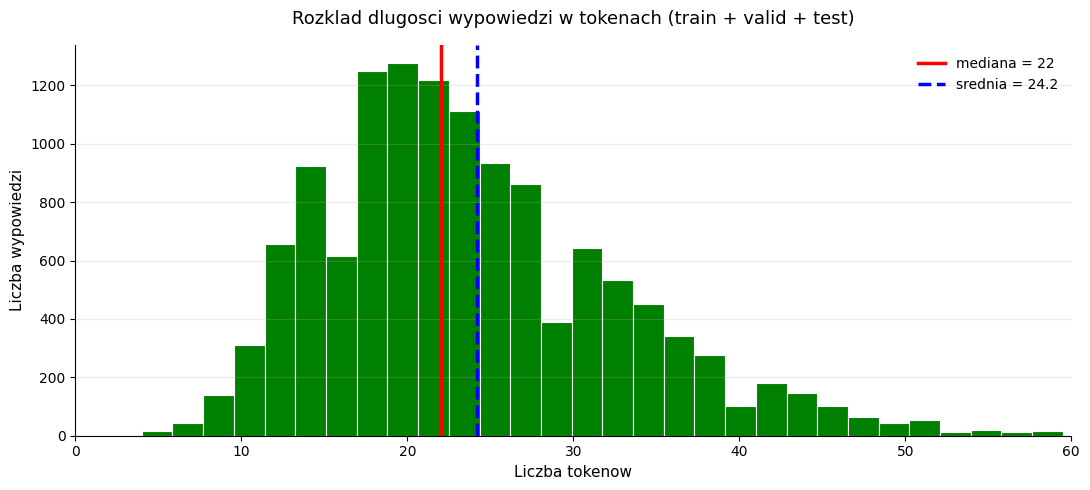

wypowiedzi > 128 tokenow: 6 (0.05%)


In [37]:
clipped = lengths_arr[lengths_arr <= 80]
median = int(np.median(lengths_arr))
mean = np.mean(lengths_arr)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(clipped, bins=40, color='green', edgecolor='white', linewidth=0.8)
ax.axvline(median, color='red', linestyle='-',  linewidth=2.5, label=f'mediana = {median}')
ax.axvline(mean,   color='blue', linestyle='--', linewidth=2.5, label=f'srednia = {mean:.1f}')

ax.set_xlabel('Liczba tokenow', fontsize=11)
ax.set_ylabel('Liczba wypowiedzi', fontsize=11)
ax.set_title('Rozklad dlugosci wypowiedzi w tokenach (train + valid + test)', fontsize=13, pad=15)
ax.set_xlim(0, 60)
ax.legend(fontsize=10, frameon=False)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(f'wypowiedzi > 128 tokenow: {(lengths_arr > 128).sum()} ({(lengths_arr > 128).mean()*100:.2f}%)')

In [17]:
example = tokenizer(
    train['statement'].iloc[0],
    padding='max_length',
    max_length=256,
    truncation=True,
    return_tensors='pt'
)

print('Tekst:         ', train['statement'].iloc[0])
print('\ninput_ids:     ', example['input_ids'][0].tolist())
print('\nattention_mask:', example['attention_mask'][0].tolist())

Tekst:          Says the Annies List political group supports third-trimester abortions on demand.

input_ids:      [0, 104, 4113, 5, 3921, 918, 9527, 559, 333, 4548, 371, 12, 4328, 38417, 17600, 15, 1077, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,

## Laczenie statement + subject + context i tokenizacja

In [19]:
import torch

def combine_text(row):
    speaker = row.get('speaker', '') if pd.notna(row.get('speaker')) else 'unknown'
    party = row.get('party', '') if pd.notna(row.get('party')) else 'unknown'
    lies = (row.get('false_counts', 0) or 0) + (row.get('pants_on_fire_counts', 0) or 0)
    truths = (row.get('mostly_true_counts', 0) or 0) + (row.get('half_true_counts', 0) or 0)

    parts = [f"{speaker} ({party}, past lies: {lies}, past truths: {truths}): {row['statement']}"]
    if pd.notna(row.get('subject')):
        parts.append('Subject: ' + str(row['subject']))
    if pd.notna(row.get('context')):
        parts.append('Context: ' + str(row['context']))
    return ' '.join(parts)

train['combined'] = train.apply(combine_text, axis=1)
valid['combined'] = valid.apply(combine_text, axis=1)
test['combined']  = test.apply(combine_text, axis=1)

print('Przyklad combined:')
print(train['combined'].iloc[0])

def tokenize_set(df):  #tokenizacja z uwzglednieniem cache
    return tokenizer(
        list(df['combined']),
        padding='max_length',
        max_length=128,
        truncation=True,
        return_tensors='pt'
    )

def tokenize_cached(df, name):
    path = os.path.join(TOK_DIR, f'{name}.pt')
    if os.path.exists(path):
        print(f'cache hit: {name}')
        return torch.load(path, weights_only=False)
    enc = tokenize_set(df)
    torch.save(enc, path)
    print(f'zapisano: {name}')
    return enc

tokenize_trainset = tokenize_cached(train, 'train_2cl')
tokenize_validset = tokenize_cached(valid, 'valid_2cl')
tokenize_testset  = tokenize_cached(test,  'test_2cl')

print('\ntrain:', tokenize_trainset['input_ids'].shape)
print('valid:', tokenize_validset['input_ids'].shape)
print('test :', tokenize_testset['input_ids'].shape)

Przyklad combined:
dwayne-bohac (republican, past lies: 1.0, past truths: 0): Says the Annies List political group supports third-trimester abortions on demand. Subject: abortion Context: a mailer
cache hit: train_2cl
cache hit: valid_2cl
cache hit: test_2cl

train: torch.Size([10240, 128])
valid: torch.Size([1284, 128])
test : torch.Size([1267, 128])


zamiana kolumn na torchowe tensory:

In [20]:
y_train = torch.tensor(train['label'].tolist())
y_valid = torch.tensor(valid['label'].tolist())
y_test  = torch.tensor(test['label'].tolist())

print('y_train:', y_train.shape, '| rozklad:', torch.unique(y_train, return_counts=True))
print('y_valid:', y_valid.shape, '| rozklad:', torch.unique(y_valid, return_counts=True))
print('y_test :', y_test.shape,  '| rozklad:', torch.unique(y_test, return_counts=True))

y_train: torch.Size([10240]) | rozklad: (tensor([0, 1]), tensor([4488, 5752]))
y_valid: torch.Size([1284]) | rozklad: (tensor([0, 1]), tensor([616, 668]))
y_test : torch.Size([1267]) | rozklad: (tensor([0, 1]), tensor([553, 714]))


# Etykiety dla wersji z 6 klasami:

In [21]:
y_train_6cl = torch.tensor(train_6cl['label'].tolist())
y_valid_6cl = torch.tensor(valid_6cl['label'].tolist())
y_test_6cl  = torch.tensor(test_6cl['label'].tolist())

print('y_train_6cl rozklad:', torch.unique(y_train_6cl, return_counts=True))

y_train_6cl rozklad: (tensor([0, 1, 2, 3, 4, 5]), tensor([ 839, 1995, 1654, 2114, 1962, 1676]))


#Tokenizacja wersji z 6 klasami:

In [22]:
train_6cl['combined'] = train_6cl.apply(combine_text, axis=1)
valid_6cl['combined'] = valid_6cl.apply(combine_text, axis=1)
test_6cl['combined']  = test_6cl.apply(combine_text, axis=1)

tokenize_trainset_6cl = tokenize_cached(train_6cl, 'train_6cl')
tokenize_validset_6cl = tokenize_cached(valid_6cl, 'valid_6cl')
tokenize_testset_6cl  = tokenize_cached(test_6cl,  'test_6cl')

print('6cl train:', tokenize_trainset_6cl['input_ids'].shape)

zapisano: train_6cl
zapisano: valid_6cl
zapisano: test_6cl
6cl train: torch.Size([10240, 128])


#Zapis danych na drive:

In [23]:
torch.save(y_train, os.path.join(TOK_DIR, 'y_train_2cl.pt'))
torch.save(y_valid, os.path.join(TOK_DIR, 'y_valid_2cl.pt'))
torch.save(y_test,  os.path.join(TOK_DIR, 'y_test_2cl.pt'))

torch.save(y_train_6cl, os.path.join(TOK_DIR, 'y_train_6cl.pt'))
torch.save(y_valid_6cl, os.path.join(TOK_DIR, 'y_valid_6cl.pt'))
torch.save(y_test_6cl,  os.path.join(TOK_DIR, 'y_test_6cl.pt'))

train.to_parquet(os.path.join(TOK_DIR, 'df_train_2cl.parquet'))
valid.to_parquet(os.path.join(TOK_DIR, 'df_valid_2cl.parquet'))
test.to_parquet(os.path.join(TOK_DIR, 'df_test_2cl.parquet'))

train_6cl.to_parquet(os.path.join(TOK_DIR, 'df_train_6cl.parquet'))
valid_6cl.to_parquet(os.path.join(TOK_DIR, 'df_valid_6cl.parquet'))
test_6cl.to_parquet(os.path.join(TOK_DIR, 'df_test_6cl.parquet'))

print('Zapisano wszystko do:', TOK_DIR)
print(os.listdir(TOK_DIR))

Zapisano wszystko do: /content/drive/MyDrive/fakenews_cache/tokenized
['train_2cl.pt', 'valid_2cl.pt', 'test_2cl.pt', 'train_6cl.pt', 'valid_6cl.pt', 'test_6cl.pt', 'y_train_2cl.pt', 'y_valid_2cl.pt', 'y_test_2cl.pt', 'y_train_6cl.pt', 'y_valid_6cl.pt', 'y_test_6cl.pt', 'df_train_2cl.parquet', 'df_valid_2cl.parquet', 'df_test_2cl.parquet', 'df_train_6cl.parquet', 'df_valid_6cl.parquet', 'df_test_6cl.parquet']
